In [1]:
import numpy as np
import matplotlib.pyplot as plt

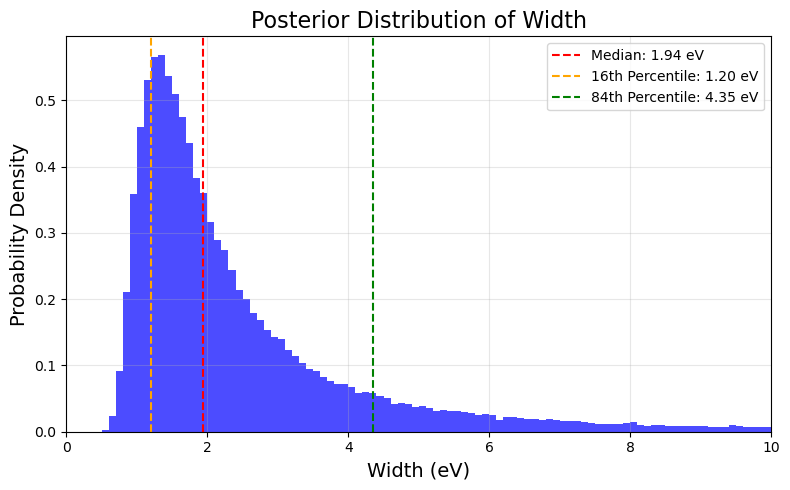

In [9]:
lifetimes = np.loadtxt('results/lifetime_samples.txt')[:,1]

hbar = 0.6582119514  # eV*fs
width = hbar / lifetimes # eV

plt.figure(figsize=(8,5))
plt.hist(width, bins=100, range=(0,10), density=True, alpha=0.7, color='blue')
plt.xlabel('Width (eV)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('Posterior Distribution of Width', fontsize=16)
plt.grid(alpha=0.3)

# Find 50th percentile (median) and 16th/84th percentiles for 1-sigma credible interval
median_width = np.percentile(width, 50)
lower_1sigma = np.percentile(width, 16)
upper_1sigma = np.percentile(width, 84)

# Plot vertical lines for median and 1-sigma interval
plt.axvline(median_width, color='red', linestyle='--', label=f'Median: {median_width:.2f} eV')
plt.axvline(lower_1sigma, color='orange', linestyle='--', label=f'16th Percentile: {lower_1sigma:.2f} eV')
plt.axvline(upper_1sigma, color='green', linestyle='--', label=f'84th Percentile: {upper_1sigma:.2f} eV')

plt.legend()

plt.xlim(0, 10)
plt.tight_layout()
plt.savefig('results/width_posterior.png', dpi=300)
plt.show()

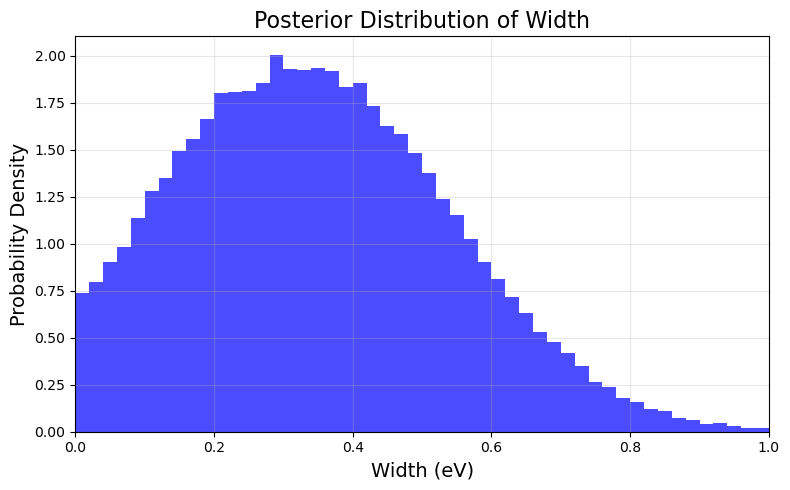

In [8]:
lifetimes = np.loadtxt('results/lifetime_samples.txt')[:,1]

hbar = 0.6582119514  # eV*fs
width = lifetimes # eV

plt.figure(figsize=(8,5))
plt.hist(width, bins=50, range=(0,1), density=True, alpha=0.7, color='blue')
plt.xlabel('Width (eV)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('Posterior Distribution of Width', fontsize=16)
plt.grid(alpha=0.3)
#plt.yscale('log')
plt.axvline(2.4)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('results/width_posterior.png', dpi=300)
plt.show()

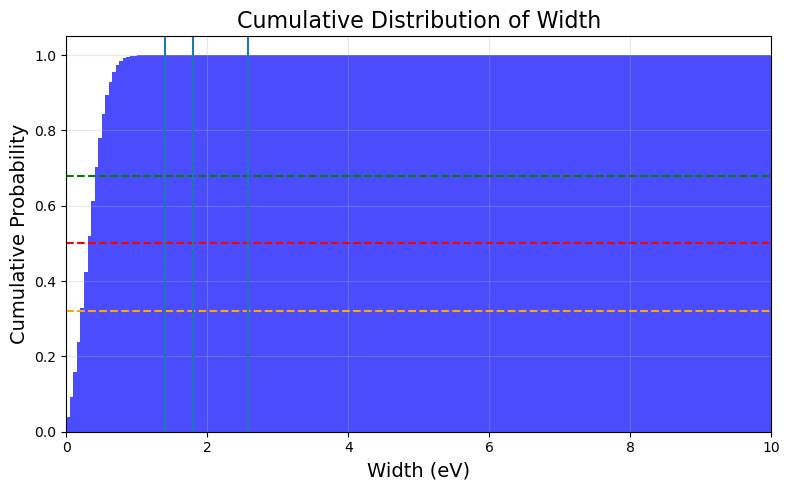

In [4]:
# Plot the cumulative distribution function (CDF) of the width
plt.figure(figsize=(8,5))
plt.hist(width, bins=2000, range=(0,100), density=True, alpha=0.7, color='blue', cumulative=True)
plt.xlabel('Width (eV)', fontsize=14)
plt.ylabel('Cumulative Probability', fontsize=14)
plt.title('Cumulative Distribution of Width', fontsize=16)
plt.axhline(0.5, color='red', linestyle='--', label='Median')
plt.axhline(0.68, color='green', linestyle='--', label='68% Credible Interval')
plt.axhline(0.32, color='orange', linestyle='--', label='32% Credible Interval')
plt.grid(alpha=0.3)
plt.axvline(1.4)
plt.axvline(1.8)
plt.axvline(2.575)
plt.xlim(0, 10)
plt.tight_layout()
plt.savefig('results/width_cdf.png', dpi=300)
plt.show()

Our distribution: mean = 0.32 fs, std = 0.21 fs


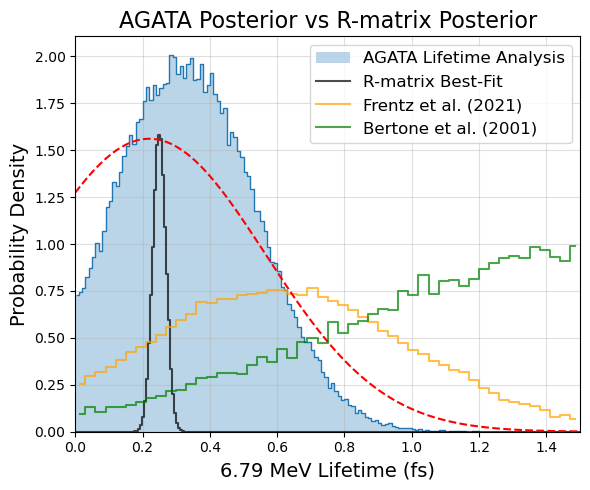

In [5]:
lifetimes = np.loadtxt('results/lifetime_samples.txt')[:,1]

frentz = np.random.normal(loc=0.6, scale=0.4, size=50000)  # Simulated Frentz distribution
bertone = np.random.normal(loc=1.6, scale=0.75, size=50000)  # Simulated Bertone distribution
r_matrix = np.random.normal(loc=0.25, scale=0.02, size=50000)  # Simulated R-matrix distribution

x_min, x_max = 0, 1.5
nbins = 50

# Fit with Gaussians
from scipy.optimize import curve_fit
from scipy.stats import norm

# Fit with curve_fit
def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

# Fit Our distribution
hist_our, bin_edges_our = np.histogram(lifetimes, bins=nbins * 4, range=(x_min, x_max), density=True)
bin_centers_our = (bin_edges_our[:-1] + bin_edges_our[1:]) / 2
mask_fit = (bin_centers_our > 0) & (bin_centers_our < 0.8)
start_mu, start_sigma = 0.22, 0.345
#start_mu, start_sigma = 0.35, 0.25
popt_our, _ = curve_fit(gaussian, bin_centers_our[mask_fit], hist_our[mask_fit], p0=[start_mu, start_sigma])
our_mu, our_std = popt_our

# Fit Our distribution with a Gaussian
x = np.linspace(x_min, x_max, 1000)
pdf_our = norm.pdf(x, start_mu, start_sigma)

# Print mean and std
print(f"Our distribution: mean = {our_mu:.2f} fs, std = {our_std:.2f} fs")

plt.figure(figsize=(6,5))
plt.hist(lifetimes, bins=nbins * 3, range=(x_min, x_max), density=True, alpha=0.3, color='tab:blue', label='AGATA Lifetime Analysis')

# Make step plot for lifetime samples
hist, bin_edges = np.histogram(lifetimes, bins=nbins * 3, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, hist, where='mid', color='tab:blue', alpha=1, lw=1)

# Create numpy histogram and then plt.step
hist, bin_edges = np.histogram(r_matrix, bins=nbins * 5, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, 0.8e-1 * hist, where='mid', color='black', alpha=0.7, label='R-matrix Best-Fit')

# Plot steps for Frentz and Bertone
hist_frentz, bin_edges_frentz = np.histogram(frentz, bins=nbins, range=(x_min, x_max), density=True)
bin_centers_frentz = (bin_edges_frentz[:-1] + bin_edges_frentz[1:]) / 2
plt.step(bin_centers_frentz, 0.7 * hist_frentz, where='mid', color='orange', alpha=0.7, label='Frentz et al. (2021)')
hist_bertone, bin_edges_bertone = np.histogram(bertone, bins=nbins, range=(x_min, x_max), density=True)
bin_centers_bertone = (bin_edges_bertone[:-1] + bin_edges_bertone[1:]) / 2
plt.step(bin_centers_bertone, 0.8 * hist_bertone, where='mid', color='green', alpha=0.7, label='Bertone et al. (2001)')

# Plot Gaussian fit
plt.plot(x, 1.35 * pdf_our, color='red', linestyle='--')
plt.xlabel('6.79 MeV Lifetime (fs)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('AGATA Posterior vs R-matrix Posterior', fontsize=16)
plt.grid(alpha=0.4)
plt.legend(fontsize=12)
plt.xlim(x_min, x_max)
plt.tight_layout()
#plt.savefig('results/lifetime_comparison.png', dpi=300)
plt.show()

Our distribution: mean = 0.34 fs, std = 0.24 fs


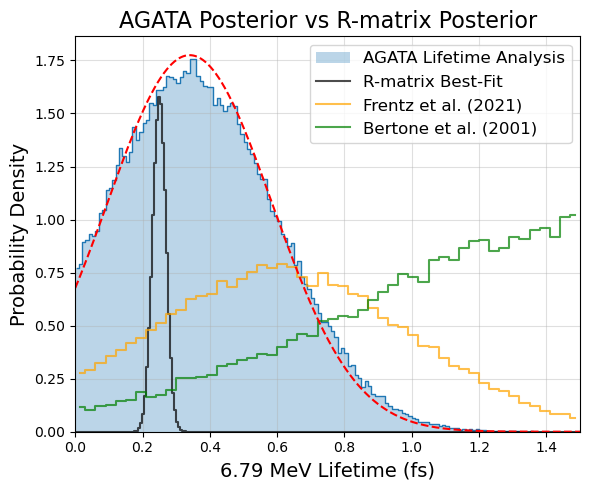

In [6]:
lifetimes = np.loadtxt('results/lifetime_samples_frentz.txt')[:,1]

frentz = np.random.normal(loc=0.6, scale=0.4, size=50000)  # Simulated Frentz distribution
bertone = np.random.normal(loc=1.6, scale=0.75, size=50000)  # Simulated Bertone distribution
r_matrix = np.random.normal(loc=0.25, scale=0.02, size=50000)  # Simulated R-matrix distribution

x_min, x_max = 0, 1.5
nbins = 50

# Fit with Gaussians
from scipy.optimize import curve_fit
from scipy.stats import norm

# Fit with curve_fit
def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

# Fit Our distribution
hist_our, bin_edges_our = np.histogram(lifetimes, bins=nbins * 4, range=(x_min, x_max), density=True)
bin_centers_our = (bin_edges_our[:-1] + bin_edges_our[1:]) / 2
mask_fit = (bin_centers_our > 0) & (bin_centers_our < 0.8)
start_mu, start_sigma = 0.34, 0.245
#start_mu, start_sigma = 0.35, 0.25
popt_our, _ = curve_fit(gaussian, bin_centers_our[mask_fit], hist_our[mask_fit], p0=[start_mu, start_sigma])
our_mu, our_std = popt_our

# Fit Our distribution with a Gaussian
x = np.linspace(x_min, x_max, 1000)
pdf_our = norm.pdf(x, start_mu, start_sigma)

# Print mean and std
print(f"Our distribution: mean = {our_mu:.2f} fs, std = {our_std:.2f} fs")

plt.figure(figsize=(6,5))
plt.hist(lifetimes, bins=nbins * 3, range=(x_min, x_max), density=True, alpha=0.3, color='tab:blue', label='AGATA Lifetime Analysis')

# Make step plot for lifetime samples
hist, bin_edges = np.histogram(lifetimes, bins=nbins * 3, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, hist, where='mid', color='tab:blue', alpha=1, lw=1)

# Create numpy histogram and then plt.step
hist, bin_edges = np.histogram(r_matrix, bins=nbins * 5, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, 0.8e-1 * hist, where='mid', color='black', alpha=0.7, label='R-matrix Best-Fit')

# Plot steps for Frentz and Bertone
hist_frentz, bin_edges_frentz = np.histogram(frentz, bins=nbins, range=(x_min, x_max), density=True)
bin_centers_frentz = (bin_edges_frentz[:-1] + bin_edges_frentz[1:]) / 2
plt.step(bin_centers_frentz, 0.7 * hist_frentz, where='mid', color='orange', alpha=0.7, label='Frentz et al. (2021)')
hist_bertone, bin_edges_bertone = np.histogram(bertone, bins=nbins, range=(x_min, x_max), density=True)
bin_centers_bertone = (bin_edges_bertone[:-1] + bin_edges_bertone[1:]) / 2
plt.step(bin_centers_bertone, 0.8 * hist_bertone, where='mid', color='green', alpha=0.7, label='Bertone et al. (2001)')

# Plot Gaussian fit
plt.plot(x, 1.09 * pdf_our, color='red', linestyle='--')
plt.xlabel('6.79 MeV Lifetime (fs)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('AGATA Posterior vs R-matrix Posterior', fontsize=16)
plt.grid(alpha=0.4)
plt.legend(fontsize=12)
plt.xlim(x_min, x_max)
plt.tight_layout()
#plt.savefig('results/lifetime_comparison.png', dpi=300)
plt.show()

Our distribution: mean = 0.32 fs, std = 0.21 fs


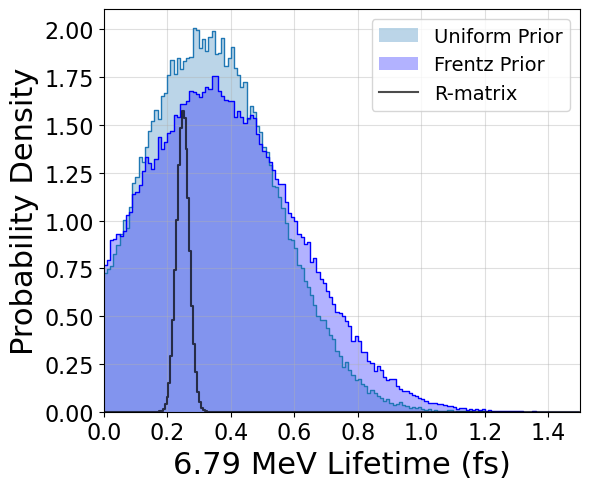

In [7]:
lifetimes_with_frentz = np.loadtxt('results/lifetime_samples_frentz.txt')[:,1]
lifetimes = np.loadtxt('results/lifetime_samples.txt')[:,1]


frentz = np.random.normal(loc=0.6, scale=0.4, size=50000)  # Simulated Frentz distribution
bertone = np.random.normal(loc=1.6, scale=0.75, size=50000)  # Simulated Bertone distribution
r_matrix = np.random.normal(loc=0.25, scale=0.02, size=50000)  # Simulated R-matrix distribution

x_min, x_max = 0, 1.5
nbins = 50

# Fit with Gaussians
from scipy.optimize import curve_fit
from scipy.stats import norm

# Fit with curve_fit
def gaussian(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

# Fit Our distribution
hist_our, bin_edges_our = np.histogram(lifetimes, bins=nbins * 4, range=(x_min, x_max), density=True)
bin_centers_our = (bin_edges_our[:-1] + bin_edges_our[1:]) / 2
mask_fit = (bin_centers_our > 0) & (bin_centers_our < 0.8)
start_mu, start_sigma = 0.34, 0.245
#start_mu, start_sigma = 0.35, 0.25
popt_our, _ = curve_fit(gaussian, bin_centers_our[mask_fit], hist_our[mask_fit], p0=[start_mu, start_sigma])
our_mu, our_std = popt_our

# Fit Our distribution with a Gaussian
x = np.linspace(x_min, x_max, 1000)
pdf_our = norm.pdf(x, start_mu, start_sigma)

# Print mean and std
print(f"Our distribution: mean = {our_mu:.2f} fs, std = {our_std:.2f} fs")

plt.figure(figsize=(6,5))
plt.hist(lifetimes, bins=nbins * 3, range=(x_min, x_max), density=True, alpha=0.3, color='tab:blue', label='Uniform Prior')
plt.hist(lifetimes_with_frentz, bins=nbins * 3, range=(x_min, x_max), density=True, alpha=0.3, color='blue', label='Frentz Prior')


# Make step plot for lifetime samples
hist, bin_edges = np.histogram(lifetimes, bins=nbins * 3, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, hist, where='mid', color='tab:blue', alpha=1, lw=1)

hist, bin_edges = np.histogram(lifetimes_with_frentz, bins=nbins * 3, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, hist, where='mid', color='blue', alpha=1, lw=1)

# Create numpy histogram and then plt.step
hist, bin_edges = np.histogram(r_matrix, bins=nbins * 5, range=(x_min, x_max), density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.step(bin_centers, 0.8e-1 * hist, where='mid', color='black', alpha=0.7, label='R-matrix')

# Plot steps for Frentz and Bertone
#hist_frentz, bin_edges_frentz = np.histogram(frentz, bins=nbins, range=(x_min, x_max), density=True)
#bin_centers_frentz = (bin_edges_frentz[:-1] + bin_edges_frentz[1:]) / 2
#plt.step(bin_centers_frentz, 0.7 * hist_frentz, where='mid', color='orange', alpha=0.7, label='Frentz et al. (2021)')
#hist_bertone, bin_edges_bertone = np.histogram(bertone, bins=nbins, range=(x_min, x_max), density=True)
#bin_centers_bertone = (bin_edges_bertone[:-1] + bin_edges_bertone[1:]) / 2
#lt.step(bin_centers_bertone, 0.8 * hist_bertone, where='mid', color='green', alpha=0.7, label='Bertone et al. (2001)')

# Plot Gaussian fit
#plt.plot(x, 1.09 * pdf_our, color='red', linestyle='--')
plt.xlabel('6.79 MeV Lifetime (fs)', fontsize=22)
plt.ylabel('Probability Density', fontsize=22)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.title('AGATA Posterior vs R-matrix Posterior', fontsize=16)
plt.grid(alpha=0.4)
plt.legend(fontsize=14)
plt.xlim(x_min, x_max)
plt.tight_layout()
plt.savefig('results/lifetime_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()